# xfig_28 — Saturation Curves with Bootstrap Significance Markers

Saturation curves with 95% CI bands. Between adjacent context pairs,
a `**` marker appears where CIs do NOT overlap (significant improvement);
`ns` where they do overlap.

If bootstrap CIs are not in analysis.csv yet (columns `mean_prob_auroc_ci_lo/hi`),
the notebook falls back to annotating the point values instead.

Idea #28 from `docs/NEW_PLOT_IDEAS.md`.

**Data**: `analysis.csv`, k=all, with optional CI columns.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

# ── Workspace root: auto-detect by looking for final_results/ ─────────────────
def _find_workspace():
    candidate = Path.cwd().resolve()
    for _ in range(10):
        if (candidate / "final_results").exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent
    return Path("/Users/boshra/NSRR-workspace").resolve()

WORKSPACE_ROOT = _find_workspace()
NSRR_TOOLS     = WORKSPACE_ROOT / "NSRR-tools"
EXPLORE_DIR    = NSRR_TOOLS / "results" / "paper_figures" / "explore"
FINAL_OUT      = EXPLORE_DIR / "final"
FINAL_OUT.mkdir(parents=True, exist_ok=True)
TABLES_DIR     = NSRR_TOOLS / "results" / "tables"

# Add explore utils to path
_nb_dir = EXPLORE_DIR / "notebooks"
sys.path.insert(0, str(_nb_dir))

from utils.data_explore import (
    set_root, load_analysis, load_analysis_all_k,
    load_heatmap, load_parquets, load_modality_table,
    subject_predictions, subject_correctness_matrix, CONTEXT_TO_MIN, CTX_ORDER,
)
from utils import panels_explore as xp

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import seaborn as sns

set_root(WORKSPACE_ROOT)
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "serif",
    "font.size": 8,
    "axes.labelsize": 7,
})

# ── Constants ──────────────────────────────────────────────────────────────────
MAIN_TASKS = ["sex_binary", "bmi_binary", "age_class",
              "sleep_efficiency_binary", "apnea_binary"]
TASK_LABEL = xp.TASK_LABEL

_ok = (WORKSPACE_ROOT / "final_results").exists()
print(f"WORKSPACE_ROOT : {WORKSPACE_ROOT}")
print(f"final_results/ : {'✓ found' if _ok else '✗ NOT FOUND'}")


WORKSPACE_ROOT : /Users/boshra/NSRR-workspace
final_results/ : ✓ found


In [3]:
# ── Config ────────────────────────────────────────────────────────────────────
TASKS  = MAIN_TASKS
HEAD   = "transformer"
N_COLS = 3
N_ROWS = (len(TASKS) + N_COLS - 1) // N_COLS

df = load_analysis("phase0_v3", split="test", k="all")

has_ci = "mean_prob_auroc_ci_lo" in df.columns and df["mean_prob_auroc_ci_lo"].notna().any()
print(f"Bootstrap CIs available: {has_ci}")
print(f"CI coverage: {df['mean_prob_auroc_ci_lo'].notna().sum()} / {len(df)} rows")

Bootstrap CIs available: True
CI coverage: 126 / 126 rows


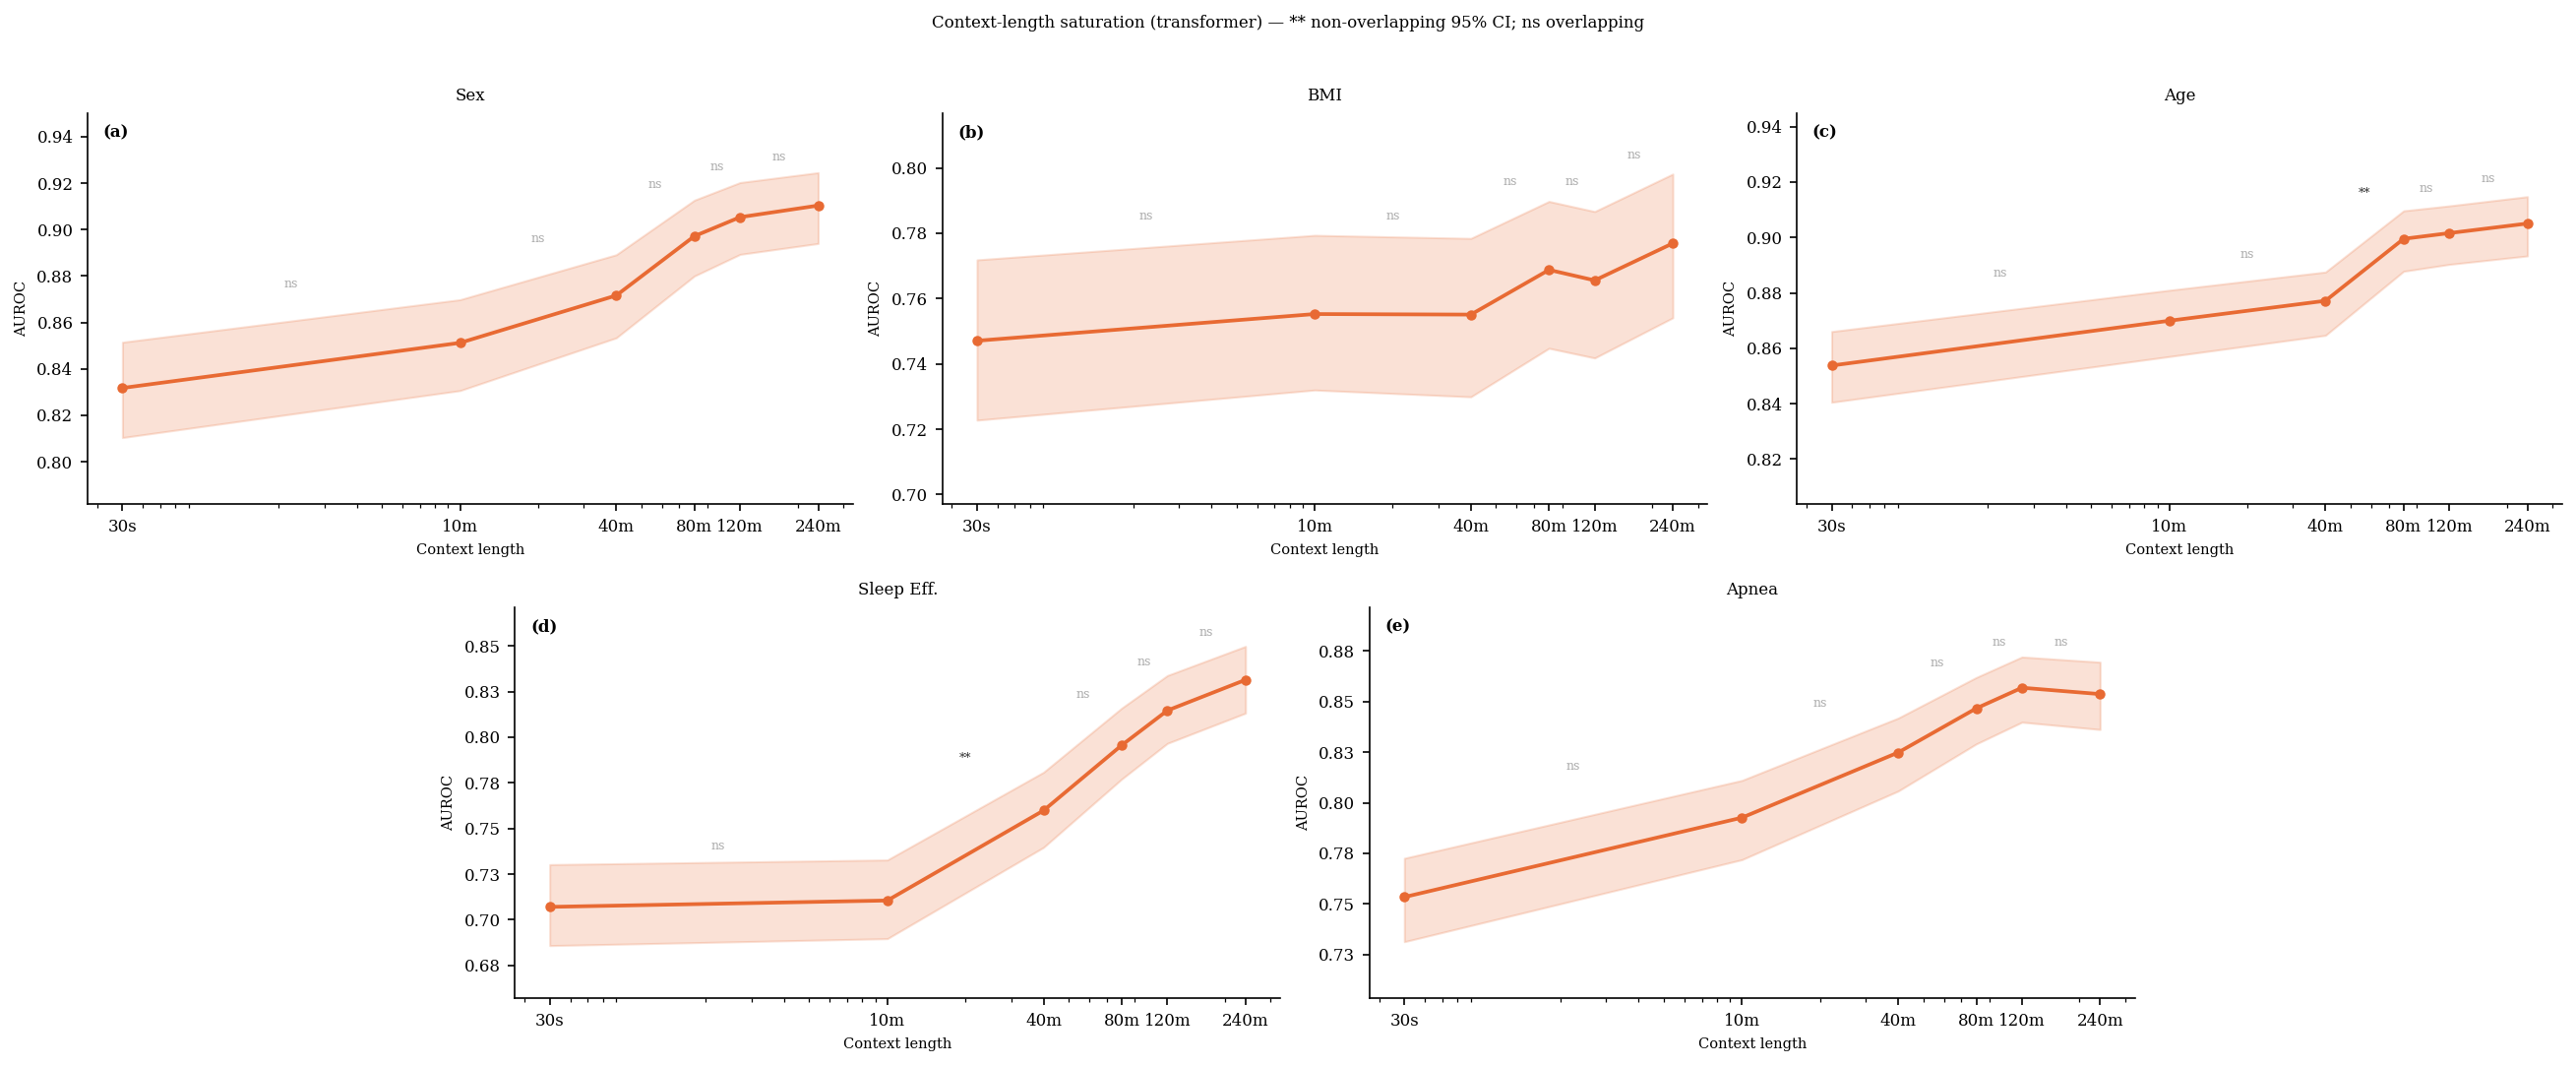

In [12]:
labels = [chr(97 + i) for i in range(len(TASKS))]
n_last = len(TASKS) % N_COLS or N_COLS
n_full = len(TASKS) // N_COLS

mosaic = []
for row in range(n_full):
    rl = labels[row * N_COLS:(row + 1) * N_COLS]
    mosaic.append([l for l in rl for _ in range(2)])
if n_last < N_COLS:
    pad = N_COLS - n_last
    ll  = labels[n_full * N_COLS:]
    mosaic.append(["."] * pad + [l for l in ll for _ in range(2)] + ["."] * pad)

fig, axd = plt.subplot_mosaic(mosaic, figsize=(7.0*2.5, N_ROWS * 3.5))

for i, (lbl, task) in enumerate(zip(labels, TASKS)):
    ax = axd[lbl]
    xp.saturation_significance_panel(ax, df, task, head=HEAD)
    ax.set_title(TASK_LABEL.get(task, task), fontsize=8)
    ax.text(0.02, 0.97, f"({lbl})", transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="top")

fig.suptitle(
    f"Context-length saturation ({HEAD}) — ** non-overlapping 95% CI; ns overlapping",
    fontsize=8, y=1.02,
)
fig.tight_layout(h_pad=1.5, w_pad=1.0)
plt.show()

In [13]:
# ── Run when figure looks good ──────────────────────────────────
fig.savefig(str(FINAL_OUT / 'xfig_28_significance_markers.pdf'), bbox_inches='tight')
fig.savefig(str(FINAL_OUT / 'xfig_28_significance_markers.png'), dpi=150, bbox_inches='tight')
print('Saved →', FINAL_OUT / 'xfig_28_significance_markers.pdf')

Saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/explore/final/xfig_28_significance_markers.pdf
